In [5]:
import pandas as pd
import requests
import json
from datetime import datetime, timedelta

import sys, os
sys.path.append(os.path.abspath("../src"))

In [62]:
import numpy as np

def np_slope(y):
    if np.isnan(y).any():
        return np.nan
    return np.polyfit(np.arange(len(y)), y, 1)[0]

In [ ]:
import time

from tqdm import tqdm


API = "https://en.wikipedia.org/w/api.php"
HEADERS = {"User-Agent": "thinking-bee/0.1 (t.j.wies@gmail.com)"}

def get_template_links(template_title: str) -> list[str]:
    params = {
        "action": "query",
        "format": "json",
        "prop": "links",
        "titles": template_title,
        "pllimit": "max",
        "plnamespace": 0,   # main/article namespace only
        "formatversion": 2,
    }

    titles = []
    while True:
        resp = requests.get(API, params=params, headers=HEADERS, timeout=20)
        resp.raise_for_status()
        data = resp.json()

        pages = data.get("query", {}).get("pages", [])
        if pages:
            links = pages[0].get("links", [])
            titles.extend(link["title"] for link in links)

        if "continue" in data:
            params.update(data["continue"])
        else:
            break

    return sorted(set(titles))

def get_revision_diff(parent_id, rev_id):
    params = {
        "action": "compare",
        "format": "json",
        "fromrev": parent_id,
        "torev": rev_id,
        "prop": "diff|ids|title",
        "formatversion": "2",
    }

    resp = requests.get(API, params=params, headers=HEADERS, timeout=10)
    resp.raise_for_status()
    data = resp.json()

    compare = data.get("compare", {})
    return compare.get("*") or compare.get("body") or compare.get("diff")


def get_revisions(page_title, talk=False, include_diff=False, sleep_sec=0.0):
    if talk and not page_title.startswith("Talk:"):
        page_title = "Talk:" + page_title

    params = {
        "action": "query",
        "format": "json",
        "prop": "revisions",
        "titles": page_title,
        "rvprop": "ids|timestamp|user|comment|size",
        "rvlimit": "max",
        "formatversion": "2",
    }

    all_revisions = []

    while True:
        resp = requests.get(API, params=params, headers=HEADERS, timeout=10)
        resp.raise_for_status()
        data = resp.json()

        pages = data.get("query", {}).get("pages", [])
        if pages and "revisions" in pages[0]:
            all_revisions.extend(pages[0]["revisions"])

        if "continue" in data:
            params.update(data["continue"])
        else:
            break

    df = pd.DataFrame(all_revisions)

    if df.empty:
        return df

    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
    df["page_title"] = page_title

    if include_diff:
        diffs = []
        for _, row in df.iterrows():
            rev_id = row.get("revid")
            parent_id = row.get("parentid")

            if pd.isna(rev_id) or pd.isna(parent_id) or parent_id == 0:
                diffs.append(None)
            else:
                try:
                    diff_html = get_revision_diff(int(parent_id), int(rev_id))
                    diffs.append(diff_html)
                    if sleep_sec > 0:
                        time.sleep(sleep_sec)
                except Exception:
                    diffs.append(None)

        df["diff_html"] = diffs

    df["comment"] = df["comment"].fillna("")
    df["comment_len"] = df["comment"].str.len()
    df["has_reply"] = df["comment"].str.contains("Reply", case=False, regex=False).astype(int)
    df["has_revert"] = df["comment"].str.contains("revert", case=False, regex=True).astype(int)
    df["size_change"] = df["size"].diff().abs()

    return df

def format_revisions(revisions):

    if revisions is None:
        return pd.DataFrame()
    if revisions.empty:
        return revisions
    df = revisions
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values("timestamp")
    df["timestamp"] = df["timestamp"].dt.floor("h")
    edits = df.groupby("timestamp").size().rename("edits")
    unique_editors = df.groupby("timestamp")["user"].nunique().rename("unique_editors")

    df["seen_before"] = df["user"].duplicated()
    df["new_editor"] = (~df["seen_before"]).astype(int)
    new_editors = df.groupby("timestamp")["new_editor"].sum().rename("new_editors")
    total_comment_len = df.groupby("timestamp")["comment_len"].sum().rename("total_comment_len")
    num_replies = df.groupby("timestamp")["has_reply"].sum().rename("num_replies")
    num_reverts = df.groupby("timestamp")["has_revert"].sum().rename("num_reverts")
    features = pd.concat([edits, unique_editors, new_editors, total_comment_len, num_replies, num_reverts], axis=1).fillna(0)

    return features.reset_index().sort_values("timestamp")

In [ ]:
titles = get_template_links("Template:Campaignbox 2026 Iran war")
from tqdm import tqdm
all_revisions = []
features = pd.DataFrame()
for i in tqdm(titles):
    rev = get_revisions(i, talk=False, include_diff=False, sleep_sec=0)
    talk_rev = get_revisions(i, talk=True, include_diff=False, sleep_sec=0)

    if not rev.empty:
        all_revisions.append(rev)
    if not talk_rev.empty:
        all_revisions.append(talk_rev)

    
all_revisions = pd.concat(all_revisions)
all_revisions["seen_before_global"] = all_revisions["user"].duplicated()
all_revisions["new_editor_global"] = (~all_revisions["seen_before_global"]).astype(int)

# clean + sort
all_revisions["timestamp"] = pd.to_datetime(all_revisions["timestamp"], utc=True)
all_revisions = all_revisions.sort_values("timestamp")

# GLOBAL new editors (across ALL pages)
all_revisions["seen_before_global"] = all_revisions["user"].duplicated()
all_revisions["new_editor_global"] = (~all_revisions["seen_before_global"]).astype(int)

# comment features
all_revisions["comment"] = all_revisions["comment"].fillna("")
all_revisions["comment_len"] = all_revisions["comment"].str.len()
all_revisions["has_reply"] = all_revisions["comment"].str.contains("Reply", case=False).astype(int)
all_revisions["has_revert"] = all_revisions["comment"].str.contains("revert", case=False).astype(int)

# size change (global ordering matters here too)
all_revisions["size_change"] = all_revisions["size"].diff().abs()

# floor timestamps to hour
all_revisions["timestamp"] = all_revisions["timestamp"].dt.floor("h")

features = all_revisions.groupby("timestamp").agg(
    edits=("user", "count"),
    unique_editors=("user", "nunique"),
    new_editors=("new_editor_global", "sum"),
    total_comment_len=("comment_len", "sum"),
    num_replies=("has_reply", "sum"),
    num_reverts=("has_revert", "sum"),
).reset_index().sort_values("timestamp")

100%|██████████| 106/106 [01:01<00:00,  1.73it/s]


In [8]:
import importlib
import poly_utils
importlib.reload(poly_utils)
from poly_utils import get_event_slugs_paginated, get_price_series_from_slug

market_dfs = []
slugs = get_event_slugs_paginated("Iran", pages=10, limit=100)

for slug in tqdm(slugs):
    slug = slug["slug"]
    prices, meta = get_price_series_from_slug(
        slug=slug,
        days=60,
        chunk_days=7,
        interval="1h",
        fidelity=60,
    )
    market_df = prices.copy()
    market_df["market_slug"] = slug
    market_df["market_title"] = meta["market_question"]

    # compute target within this market
    market_df = market_df.sort_values("timestamp")
    market_df["volatility_6h"] = market_df["price"].diff().rolling(6).std()
    market_df["target"] = market_df["volatility_6h"].shift(-1)

    market_dfs.append(market_df)

100%|██████████| 9/9 [00:21<00:00,  2.39s/it]


In [9]:
panel_df = pd.concat(market_dfs, ignore_index=True)
print(panel_df.shape)
panel_df.head()

(9494, 6)


,timestamp,price,market_slug,market_title,volatility_6h,target
0,2026-03-01 01:00:43+00:00,0.610,will-the-iranian-regime-fall-by-the-end-of-2026,Will the Iranian regime fall before 2027?,NaN,NaN
1,2026-03-01 02:00:37+00:00,0.635,will-the-iranian-regime-fall-by-the-end-of-2026,Will the Iranian regime fall before 2027?,NaN,NaN
2,2026-03-01 03:00:42+00:00,0.595,will-the-iranian-regime-fall-by-the-end-of-2026,Will the Iranian regime fall before 2027?,NaN,NaN
3,2026-03-01 04:00:38+00:00,0.585,will-the-iranian-regime-fall-by-the-end-of-2026,Will the Iranian regime fall before 2027?,NaN,NaN
4,2026-03-01 05:00:36+00:00,0.595,will-the-iranian-regime-fall-by-the-end-of-2026,Will the Iranian regime fall before 2027?,NaN,NaN


In [10]:
def validate_and_resample_panel(panel_df, freq="1h"):
    panel_df = panel_df.copy()
    panel_df["timestamp"] = pd.to_datetime(panel_df["timestamp"], utc=True)

    cleaned = []

    for slug, g in panel_df.groupby("market_slug"):
        print("\n" + "=" * 80)
        print("Market:", slug)
        print("Rows:", len(g))
        print("Time range:", g["timestamp"].min(), "→", g["timestamp"].max())

        g = g.sort_values("timestamp").drop_duplicates("timestamp").copy()
        g["delta"] = g["timestamp"].diff()

        print("\nUnique time deltas:")
        print(g["delta"].value_counts().head())

        expected = pd.Timedelta(freq)
        gaps = g[g["delta"] > expected]

        print(f"\nNumber of gaps > {freq}: {len(gaps)}")
        if len(gaps) > 0:
            print("\nExample gaps:")
            print(gaps[["timestamp", "delta"]].head())

        print("\nDuplicate timestamps:", g["timestamp"].duplicated().sum())

        # keep non-time metadata columns
        meta_cols = [c for c in g.columns if c not in ["timestamp", "price", "delta"]]

        g_clean = (
            g.set_index("timestamp")
            .resample(freq)
            .last()
            .ffill()
            .reset_index()
        )

        # restore market_slug if needed
        g_clean["market_slug"] = slug

        print("\nAfter resampling:")
        print("Rows:", len(g_clean))

        print("\nFinal time delta check:")
        print(g_clean["timestamp"].diff().value_counts().head())

        cleaned.append(g_clean)

    return pd.concat(cleaned, ignore_index=True)


panel_clean = validate_and_resample_panel(panel_df, freq="1h")

panel_clean = panel_clean.sort_values(["market_slug", "timestamp"])
panel_clean["volatility_6h"] = (
    panel_clean.groupby("market_slug")["price"]
    .transform(lambda s: s.diff().rolling(6).std())
)

panel_clean["target"] = (
    panel_clean.groupby("market_slug")["volatility_6h"]
    .shift(-1)
)


Market: iran-nuclear-test-before-2027
Rows: 1360
Time range: 2026-03-01 01:00:41+00:00 → 2026-04-29 23:52:07+00:00

Unique time deltas:
delta
0 days 01:00:00    120
0 days 01:00:01     93
0 days 01:00:02     83
0 days 00:59:58     80
0 days 00:59:59     77
Name: count, dtype: int64

Number of gaps > 1h: 651

Example gaps:
                     timestamp           delta
3414 2026-03-01 03:00:41+00:00 0 days 01:00:05
3417 2026-03-01 07:00:33+00:00 0 days 01:59:58
3418 2026-03-01 08:00:36+00:00 0 days 01:00:03
3419 2026-03-01 09:00:51+00:00 0 days 01:00:15
3422 2026-03-01 12:00:53+00:00 0 days 01:00:19

Duplicate timestamps: 0

After resampling:
Rows: 1439

Final time delta check:
timestamp
0 days 01:00:00    1438
Name: count, dtype: int64

Market: iran-nuke-before-2027
Rows: 1094
Time range: 2026-03-01 01:00:37+00:00 → 2026-04-29 23:52:08+00:00

Unique time deltas:
delta
0 days 01:00:01    69
0 days 00:59:59    56
0 days 01:00:02    51
0 days 00:59:58    50
0 days 01:00:00    45
Name: co

In [47]:
import pandas as pd
import numpy as np

# -----------------------------
# 1. Merge prices + features
# -----------------------------
# Assumes:
# panel_clean has: timestamp, market_slug, price
# features has: timestamp, edits, unique_editors, new_editors, etc.
# If features are global to all markets, merge only on timestamp.
# If features are market-specific, include market_slug and merge by market_slug too.

prices_hourly = panel_clean.copy()
prices_hourly["timestamp"] = pd.to_datetime(prices_hourly["timestamp"], utc=True)

features_hourly = (
    features.copy()
    .assign(timestamp=lambda x: pd.to_datetime(x["timestamp"], utc=True))
    .set_index("timestamp")
    .resample("1h")
    .sum()
    .fillna(0)
    .reset_index()
)

df = pd.merge_asof(
    prices_hourly.sort_values("timestamp"),
    features_hourly.sort_values("timestamp"),
    on="timestamp",
    direction="backward"
)

df = df.sort_values(["market_slug", "timestamp"]).copy()

windows = {
    "1h": 1,
    "3h": 3,
    "6h": 6,
    "12h": 12,
    # "24h": 24,
}

wiki_cols = [
    "edits",
    "unique_editors",
    "new_editors",
    "total_comment_len",
    "num_replies",
    "num_reverts",
]

new_cols = {}

# returns must be within market
new_cols["returns"] = (
    df.groupby("market_slug")["price"]
    .pct_change()
)

for label, hours in windows.items():
    g = df.groupby("market_slug", group_keys=False)

    # price targets / volatility
    new_cols[f"delta_price_{label}"] = (
        g["price"].shift(-hours) - df["price"]
    )

    new_cols[f"abs_delta_price_move_{label}"] = (
        new_cols[f"delta_price_{label}"].abs()
    )

    new_cols[f"volatility_{label}"] = (
        new_cols["returns"]
        .groupby(df["market_slug"])
        .rolling(hours, min_periods=1)
        .std()
        .reset_index(level=0, drop=True)
    )

    # wiki rolling features
    for col in wiki_cols:
        rolled = (
            df[col]
            .groupby(df["market_slug"])
            .rolling(hours, min_periods=1)
            .mean()
            .reset_index(level=0, drop=True)
        )

        new_cols[f"{col}_{label}"] = rolled
        new_cols[f"{col}_{label}_diff"] = (
            rolled.groupby(df["market_slug"]).diff()
        )

df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1).copy()

/Users/tallywiesenberg/Repositories/UMBC/MATH-490/thinking-bee/venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/tallywiesenberg/Repositories/UMBC/MATH-490/thinking-bee/venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/tallywiesenberg/Repositories/UMBC/MATH-490/thinking-bee/venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/Users/tallywiesenberg/Repositories/UMBC/MATH-490/thinking-bee/venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/Users/tallywiesenberg/Repositories/UMBC/MATH-490/thinking-bee/venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2894:

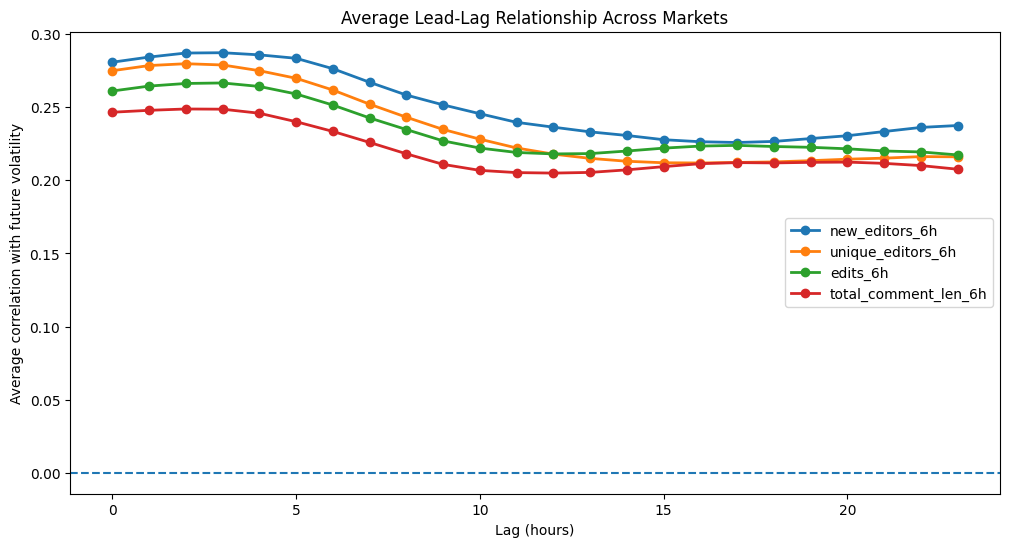

In [67]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# remove duplicate columns if repeated feature cells created them
df = df.loc[:, ~df.columns.duplicated()].copy()

features_to_plot = [
    "new_editors_6h",
    "unique_editors_6h",
    "edits_6h",
    "total_comment_len_6h",
]

max_lag = 24

plt.figure(figsize=(12, 6))

for feature in features_to_plot:
    market_corrs = {}

    for slug, g in df.groupby("market_slug"):
        g = g.sort_values("timestamp").copy()

        target = g["volatility_6h"].shift(-1)

        corrs = []
        for lag in range(max_lag):
            x = g[feature].shift(lag)
            corrs.append(x.corr(target))

        market_corrs[slug] = corrs

    corr_df = pd.DataFrame(market_corrs)

    avg_corr = corr_df.mean(axis=1)

    plt.plot(
        range(max_lag),
        avg_corr,
        marker="o",
        linewidth=2,
        label=feature
    )

plt.axhline(0, linestyle="--")
plt.xlabel("Lag (hours)")
plt.ylabel("Average correlation with future volatility")
plt.title("Average Lead-Lag Relationship Across Markets")
plt.legend()
plt.show()

In [70]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

df = df.copy()
df = df.sort_values(["market_slug", "timestamp"]).copy()

max_lag = 24
feature_cols = []

categories = ["edits", "new_editors", "unique_editors", "total_comment_len"]

# -----------------------------
# Target
# -----------------------------
df["target_raw"] = (
    df.groupby("market_slug")["volatility_6h"]
    .shift(-1)
)

df["target_z"] = (
    df.groupby("market_slug")["target_raw"]
    .transform(lambda s: (s - s.rolling(48, min_periods=12).mean()) / s.rolling(48, min_periods=12).std())
)

df["target"] = df["target_z"]

# -----------------------------
# Slope features
# -----------------------------
for cat in categories:
    slope_col = f"{cat}_slope_6h"
    df[slope_col] = (
        df.groupby("market_slug")[cat]
        .transform(lambda s: s.rolling(6, min_periods=5).apply(np_slope, raw=True))
    )

    # lag slope so it is past-only
    lagged_slope_col = f"{slope_col}_lag_1"
    df[lagged_slope_col] = (
        df.groupby("market_slug")[slope_col]
        .shift(1)
    )

    feature_cols.append(lagged_slope_col)

# -----------------------------
# Lag + EWM features
# -----------------------------
for w in windows:
    for cat in categories:
        cat_window = f"{cat}_{w}"

        for i in range(1, max_lag + 1):
            col = f"{cat_window}_lag_{i}"
            df[col] = df.groupby("market_slug")[cat_window].shift(i)
            feature_cols.append(col)

        category_past = df.groupby("market_slug")[cat_window].shift(1)

        for alpha in [i / 10 for i in range(1, 10)]:
            col = f"{cat_window}_ewm_{alpha}"
            df[col] = (
                category_past.groupby(df["market_slug"])
                .transform(lambda s: s.ewm(alpha=alpha, adjust=False).mean())
            )
            feature_cols.append(col)

df = df.copy()

# -----------------------------
# Clean model frame
# -----------------------------
model_df = pd.concat(
    [df[["market_slug", "timestamp"]], df[feature_cols], df["target"]],
    axis=1
).dropna()

model_df = model_df.sort_values("timestamp")

split = int(len(model_df) * 0.7)

train_df = model_df.iloc[:split].copy()
test_df = model_df.iloc[split:].copy()

threshold = train_df["target"].quantile(0.8)

train_df["big_move"] = (train_df["target"] > threshold).astype(int)
test_df["big_move"] = (test_df["target"] > threshold).astype(int)

print("Train class counts:")
print(train_df["big_move"].value_counts())

print("\nTest class counts:")
print(test_df["big_move"].value_counts())

if train_df["big_move"].nunique() < 2:
    raise ValueError("Training set has only one class. Lower threshold or get more data.")

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]

y_train = train_df["big_move"]
y_test = test_df["big_move"]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]

auc = roc_auc_score(y_test, y_pred_prob)
print("\nAUC:", auc)

coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coef": model.coef_[0]
}).sort_values("coef", ascending=False)

print("\nTop positive coefficients:")
print(coef_df.head(10))

print("\nTop negative coefficients:")
print(coef_df.tail(10))

Train class counts:
big_move
0    6185
1    1546
Name: count, dtype: int64

Test class counts:
big_move
0    2735
1     579
Name: count, dtype: int64

AUC: 0.5165781006779008

Top positive coefficients:
                          feature      coef
518  total_comment_len_12h_lag_20  0.728867
520  total_comment_len_12h_lag_22  0.643637
357      unique_editors_6h_lag_24  0.585463
517  total_comment_len_12h_lag_19  0.584033
324         new_editors_6h_lag_24  0.581854
289               edits_6h_lag_22  0.532834
423              edits_12h_lag_24  0.426640
290               edits_6h_lag_23  0.361844
288               edits_6h_lag_21  0.296375
519  total_comment_len_12h_lag_21  0.279974

Top negative coefficients:
                       feature      coef
456     new_editors_12h_lag_24 -0.369831
486  unique_editors_12h_lag_21 -0.400099
61      new_editors_1h_ewm_0.1 -0.508991
225   unique_editors_3h_lag_24 -0.534687
193     new_editors_3h_ewm_0.1 -0.556573
485  unique_editors_12h_lag_20 -0.64574

In [53]:
y_train_shuffled = y_train.sample(frac=1, random_state=42)

model.fit(X_train_scaled, y_train_shuffled)
y_pred_prob_shuffled = model.predict_proba(X_test_scaled)[:, 1]

print("Shuffled AUC:", roc_auc_score(y_test, y_pred_prob_shuffled))

Shuffled AUC: 0.5006359625716014


In [54]:
shuffle_aucs = []

for seed in tqdm(range(50)):
    y_perm = y_train.sample(frac=1, random_state=seed)
    m = LogisticRegression(max_iter=1000)
    m.fit(X_train_scaled, y_perm)
    pred = m.predict_proba(X_test_scaled)[:, 1]
    shuffle_aucs.append(roc_auc_score(y_test, pred))

print("Real AUC:", auc)
print("Shuffle mean:", np.mean(shuffle_aucs))
print("Shuffle max:", np.max(shuffle_aucs))

100%|██████████| 50/50 [00:25<00:00,  1.96it/s]

Real AUC: 0.5541546589817483
Shuffle mean: 0.49709627494930086
Shuffle max: 0.5272707866367808
